# Asset Feature Embedding for a Pump

This notebook demonstrates how to convert heterogeneous pump information into a compact numerical **asset embedding**. The embedding combines sensor measurements, operating conditions, and maintenance metadata into a vector that can be used for anomaly detection, failure prediction, or graph neural networks.

The example uses synthetic data so that it can run without external files. The same pipeline can later be applied to real condition-monitoring data.

## 1. Imports and reproducibility

We use NumPy and pandas for data handling, scikit-learn for preprocessing and visualization, and PyTorch to learn the embedding.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid')

## 2. Create a synthetic pump dataset

Each row represents one observation of a pump. The columns include:

- **Sensor features:** temperature, vibration, pressure, current, and flow rate.
- **Operating features:** load and operating hours.
- **Maintenance features:** days since the last maintenance event.
- **Categorical features:** pump type and plant area.
- **Target:** a simplified failure indicator used only to demonstrate supervised embedding learning.

In [2]:
n_samples = 240
rng = np.random.default_rng(42)

pump_data = pd.DataFrame({
    'asset_id': [f'P-{204 + i % 8:03d}' for i in range(n_samples)],
    'pump_type': rng.choice(['centrifugal', 'positive_displacement'], n_samples),
    'plant_area': rng.choice(['A', 'B', 'C'], n_samples),
    'temperature_c': rng.normal(72, 9, n_samples),
    'vibration_rms': rng.normal(3.0, 0.9, n_samples),
    'pressure_bar': rng.normal(11.5, 1.8, n_samples),
    'current_a': rng.normal(18, 3.0, n_samples),
    'flow_rate_m3h': rng.normal(120, 18, n_samples),
    'load_percent': rng.normal(68, 14, n_samples).clip(10, 100),
    'operating_hours': rng.integers(1000, 24000, n_samples),
    'maintenance_age_days': rng.integers(1, 180, n_samples)
})

# Create a simple synthetic failure mechanism. In real work, this would be
# replaced with an observed failure label or a remaining-useful-life target.
risk_score = (
    0.70 * pump_data['vibration_rms']
    + 0.025 * pump_data['temperature_c']
    + 0.004 * pump_data['maintenance_age_days']
    + 0.00002 * pump_data['operating_hours']
)
pump_data['failure_within_30_days'] = (
    risk_score > risk_score.quantile(0.75)
).astype(int)

pump_data.head()

,asset_id,pump_type,plant_area,temperature_c,vibration_rms,pressure_bar,current_a,flow_rate_m3h,load_percent,operating_hours,maintenance_age_days,failure_within_30_days
0,P-204,centrifugal,A,65.438245,3.557254,11.120758,15.863694,154.808283,71.317281,6738,26,0
1,P-205,positive_displacement,B,66.112682,2.694667,9.311396,22.111623,155.288723,66.831717,18714,18,0
2,P-206,positive_displacement,A,52.674399,3.957466,8.685740,16.547910,97.896002,61.840172,5772,106,0
3,P-207,centrifugal,B,70.536007,1.972256,12.734348,24.728761,103.322404,26.621336,8747,1,0
4,P-208,centrifugal,B,62.438270,3.005705,10.868286,17.994240,146.728538,50.537555,6414,116,0


## 3. Prepare numerical and categorical features

A neural network cannot directly consume strings or features with very different scales. We therefore:

1. Standardize numerical features to approximately zero mean and unit variance.
2. One-hot encode categorical features.
3. Concatenate the transformed values into one input vector for each pump.

The `asset_id` is excluded here because it is an identifier, not a physical characteristic.

In [3]:
numeric_features = [
    'temperature_c', 'vibration_rms', 'pressure_bar', 'current_a',
    'flow_rate_m3h', 'load_percent', 'operating_hours',
    'maintenance_age_days'
]
categorical_features = ['pump_type', 'plant_area']
target_column = 'failure_within_30_days'

preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', StandardScaler(), numeric_features),
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(pump_data)
y = pump_data[target_column].to_numpy(dtype=np.float32)

print('Original numerical features:', len(numeric_features))
print('Processed feature dimension:', X_processed.shape[1])
print('Failure rate:', y.mean().round(3))

Original numerical features: 8
Processed feature dimension: 13
Failure rate: 0.25


## 4. Define a learnable asset embedding

The embedding model is a small multilayer perceptron. It maps the processed input vector to a lower-dimensional vector, here with eight dimensions. A classification head uses that embedding to predict whether a failure will occur within 30 days.

During training, the model learns an embedding in which pumps with similar failure-related patterns tend to have similar representations.

In [4]:
class PumpEmbeddingModel(nn.Module):
    def __init__(self, input_dim, embedding_dim=8):
        super().__init__()

        # The encoder creates the compact asset embedding h_i.
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, embedding_dim)
        )

        # The prediction head uses the embedding for predictive maintenance.
        self.failure_head = nn.Linear(embedding_dim, 1)

    def forward(self, x):
        embedding = self.encoder(x)
        failure_logit = self.failure_head(embedding).squeeze(1)
        return embedding, failure_logit

X_tensor = torch.tensor(X_processed, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

model = PumpEmbeddingModel(input_dim=X_tensor.shape[1], embedding_dim=8)
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

## 5. Train the embedding model

This example trains on all observations for simplicity. For a real project, split the data by time or by asset to avoid leakage between training and test sets.

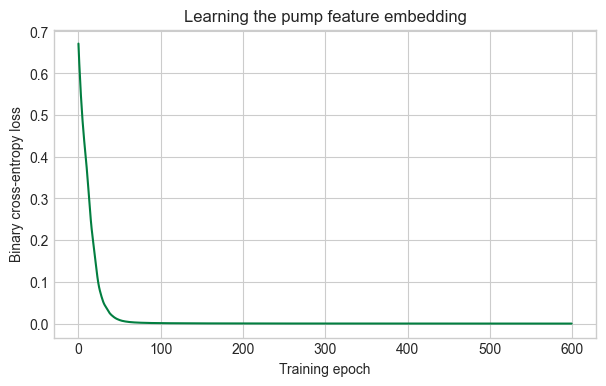

In [5]:
loss_history = []

for epoch in range(600):
    optimizer.zero_grad()
    embeddings, logits = model(X_tensor)
    loss = loss_function(logits, y_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

plt.figure(figsize=(7, 4))
plt.plot(loss_history, color='#027e40')
plt.xlabel('Training epoch')
plt.ylabel('Binary cross-entropy loss')
plt.title('Learning the pump feature embedding')
plt.show()

## 6. Inspect the learned embeddings

The original embedding has eight dimensions. PCA projects it into two dimensions only for visualization. The colors show the synthetic maintenance target. Separation suggests that the embedding has learned information useful for distinguishing higher-risk pumps.

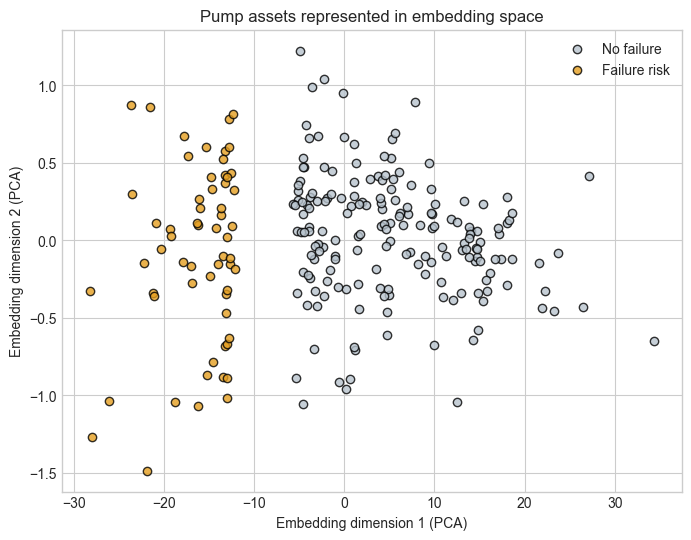

In [6]:
with torch.no_grad():
    learned_embeddings, logits = model(X_tensor)
    predicted_probability = torch.sigmoid(logits).numpy()
    learned_embeddings = learned_embeddings.numpy()

embedding_2d = PCA(n_components=2, random_state=42).fit_transform(learned_embeddings)

plt.figure(figsize=(8, 6))
for label, color, name in [(0, '#b8c4ce', 'No failure'), (1, '#e59f20', 'Failure risk')]:
    mask = y == label
    plt.scatter(
        embedding_2d[mask, 0], embedding_2d[mask, 1],
        c=color, label=name, edgecolor='black', alpha=0.8
    )

plt.xlabel('Embedding dimension 1 (PCA)')
plt.ylabel('Embedding dimension 2 (PCA)')
plt.title('Pump assets represented in embedding space')
plt.legend()
plt.show()

## 7. Inspect one pump's embedding

The embedding is a compact representation of the pump's condition and context. It is not directly interpretable feature-by-feature like the original measurements; instead, its usefulness is evaluated through downstream tasks such as failure prediction, similarity search, clustering, or graph-based reasoning.

In [7]:
example_index = 0
example_pump = pump_data.iloc[example_index]
example_embedding = learned_embeddings[example_index]

print('Pump record:')
display(example_pump.to_frame().T)

print('Learned asset embedding h_i:')
display(pd.DataFrame([example_embedding], columns=[f'h_{i+1}' for i in range(len(example_embedding))]))
print(f'Predicted failure probability: {predicted_probability[example_index]:.3f}')

Pump record:


,asset_id,pump_type,plant_area,temperature_c,vibration_rms,pressure_bar,current_a,flow_rate_m3h,load_percent,operating_hours,maintenance_age_days,failure_within_30_days
0,P-204,centrifugal,A,65.438245,3.557254,11.120758,15.863694,154.808283,71.317281,6738,26,0


Learned asset embedding h_i:


,h_1,h_2,h_3,h_4,h_5,h_6,h_7,h_8
0,-5.092644,4.88348,-4.976135,-5.416152,-6.021214,5.198319,6.458316,6.690993


Predicted failure probability: 0.000


## 8. Connecting embeddings to a maintenance graph

If pumps, motors, valves, and other assets form a graph, each node receives its own embedding:

$H^{(0)} = [h_1, h_2, \ldots, h_n]$

The adjacency matrix describes which assets are connected. A graph neural network can then aggregate information from neighboring assets, allowing the model to learn effects such as a motor problem increasing the risk of a connected pump.

In summary:

- The **asset feature vector** describes one asset.
- The **asset embedding** is a learned compact representation of that vector.
- The **graph edges** describe relationships through which information can be shared.
- The **maintenance prediction head** converts the embedding into a risk estimate.